<img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Trabajo práctico de Laboratorio 1. Teoría Moderna y Filtrado Activo

**Autor:** *Matías Alejandro Cruz*

**Grupo:** *1*

**Curso:** *R4052* 

**Año:** *2026* 

**Profesor:** *Mariano Llamedo Soria* 

**Ayudante de TPs:** *David Moharos*

**Fecha de entrega:** *07/09/2026*


## 1. Objetivos
Los objetivos generales del trabajo práctico son:

- Consolidar los conceptos de teoría moderna mediante la implementación circuital.
- Simular e implementar el filtro con componentes activos de precisión.
- Medir las partes de la función transferencia para frecuencias menores a 100 kHz.


## 2. Introducción

Este informe documenta el trabajo realizado para la Plantilla B del TP de Laboratorio 1: diseño, simulación e implementación de un filtro pasa altos Chebyshev. La topología utilizada, Multiple Feedback (MFB), no fue impuesta por la consigna sino elegida por preferencia propia.

El desarrollo sigue el orden en que se fue trabajando: cálculo teórico, verificación por simulación (Python y LTSpice), diseño del circuito impreso (Altium), y validación experimental, incluyendo el proceso de diagnóstico y corrección que fue necesario tras detectar que el filtro armado no cumplía la plantilla en la primera medición.

### Especificaciones del filtro

| Parámetro | Valor |
|---|---|
| Frecuencia de corte (fc) | 4.6 kHz |
| Frecuencia de stop (fs) | 1.2 kHz |
| Atenuación máxima en banda de paso (Amax) | 1 dB |
| Atenuación mínima en banda de stop (Amin) | 20 dB |

## 3. Diseño teórico



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches

from scipy import signal as sig

from pytc2.sistemas_lineales import analyze_sys, plot_plantilla, pretty_print_bicuad_omegayq

# Especificaciones del Filtro B
fc = 4600.0      # Hz, frecuencia de corte (borde de banda de paso)
fs = 1200.0      # Hz, frecuencia de stop (borde de banda de stop)
Amax = 1.0       # dB, rizado máximo permitido en banda de paso
Amin = 20.0      # dB, atenuación mínima requerida en banda de stop

wc = 2*np.pi*fc
ws = 2*np.pi*fs

print(f"fc = {fc} Hz, fs = {fs} Hz, Amax = {Amax} dB, Amin = {Amin} dB")

fc = 4600.0 Hz, fs = 1200.0 Hz, Amax = 1.0 dB, Amin = 20.0 dB


### 3.1 Gráfico de la plantilla


Antes de calcular el orden, visualizamos la plantilla de diseño: la región prohibida en banda de
paso (por encima de $A_{max}$ = 1 dB) y en banda de stop (por debajo de $A_{min}$ = 20 dB),
delimitadas por $f_c$ = 4.6 kHz y $f_s$ = 1.2 kHz respectivamente.

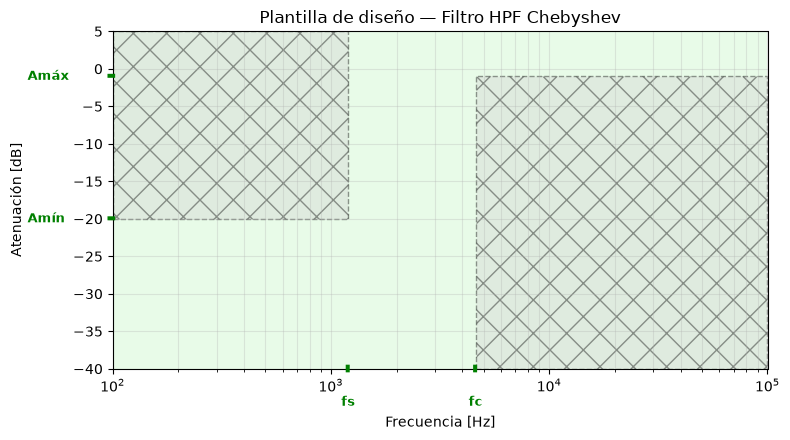

In [2]:
plt.rcParams['figure.dpi'] = 100
fig, ax = plt.subplots(figsize=(8,4.5))
ax.set_xscale("log")
ax.set_xlim(1e2, 1e5)
ax.set_ylim(-40, 5)
ax.set_xlabel("Frecuencia [Hz]", labelpad=15)
ax.set_ylabel("Atenuación [dB]", labelpad=35)
ax.set_title("Plantilla de diseño — Filtro HPF Chebyshev")
plt.sca(ax)

trans_x = ax.get_xaxis_transform()
ax.text(fc, -0.08, "fc", transform=trans_x, ha="center", va="top", fontsize=9, fontweight="bold", color="green")
ax.text(fc, 0.015, "-", transform=trans_x, ha="center", va="top", fontsize=18, fontweight="bold", color="green", rotation=90)
ax.text(fs, -0.08, "fs", transform=trans_x, ha="center", va="top", fontsize=9, fontweight="bold", color="green")
ax.text(fs, 0.015, "-", transform=trans_x, ha="center", va="top", fontsize=18, fontweight="bold", color="green", rotation=90)

trans_y = ax.get_yaxis_transform()
ax.text(-0.13, -Amax, "Amáx", transform=trans_y, ha="left", va="center", fontsize=9, fontweight="bold", color="green")
ax.text(-0.01, -Amax, "-", transform=trans_y, ha="left", va="center", fontsize=18, fontweight="bold", color="green")
ax.text(-0.13, -Amin, "Amín", transform=trans_y, ha="left", va="center", fontsize=9, fontweight="bold", color="green")
ax.text(-0.01, -Amin, "-", transform=trans_y, ha="left", va="center", fontsize=18, fontweight="bold", color="green")
 
ax.grid(True, which="both", alpha=0.3)

plot_plantilla(filter_type='highpass', fpass=fc, ripple=Amax, fstop=fs, attenuation=Amin, fs=2*1e5)


plt.tight_layout()
plt.show()

### 3.2 Función de aproximación Chebyshev

La respuesta en magnitud al cuadrado de un filtro Chebyshev normalizado es:

$$|H(j\Omega)|^2 = \frac{1}{1+\varepsilon^2 C_n^2(\Omega)}$$

donde $C_n(\Omega)$ es el polinomio de Chebyshev de grado $n$. El parámetro $\varepsilon$ queda
fijado por el rizado permitido: en $\Omega=1$ (borde de banda de paso), $C_n=1$, entonces

$$A_{max}=10\log_{10}(1+\varepsilon^2) \quad\Rightarrow\quad \varepsilon=\sqrt{10^{A_{max}/10}-1}$$

Este mismo $\varepsilon$ se reutiliza más adelante tanto para calcular el orden como para ubicar
los polos del prototipo.

In [3]:
epsilon = np.sqrt(10**(Amax/10)-1)
print(f"epsilon = {epsilon:.4f}")

epsilon = 0.5088


### 3.3 Cálculo del orden del filtro

Para un pasa altos, se trabaja con la relación de selectividad $\Omega_s = f_c/f_s$ (mayor a 1).
El orden mínimo de Chebyshev que cumple la plantilla es:

$$n \geq \frac{\mathrm{arccosh}\sqrt{\dfrac{10^{A_{min}/10}-1}{10^{A_{max}/10}-1}}}{\mathrm{arccosh}(\Omega_s)}$$

In [4]:
Omega_s = fc/fs

num = np.arccosh(np.sqrt((10**(Amin/10)-1)/epsilon**2))
den = np.arccosh(Omega_s)
n_min = num/den

n = int(np.ceil(n_min))

print(f"Omega_s = {Omega_s:.4f}")
print(f"n (mínimo teórico) = {n_min:.4f}")
print(f"n (orden a utilizar) = {n}")

Omega_s = 3.8333
n (mínimo teórico) = 1.8152
n (orden a utilizar) = 2


**Verificación:** con el orden elegido, chequeamos la atenuación real que se obtiene en $f_s$
(debe ser $\geq$ Amin):

$$A(\Omega) = 10\log_{10}\left(1+\varepsilon^2\cosh^2(n\,\mathrm{arccosh}(\Omega))\right)$$

In [5]:
def atenuacion_chebyshev(Omega, n, epsilon):
    return 10*np.log10(1 + epsilon**2 * np.cosh(n*np.arccosh(Omega))**2)

A_en_fs = atenuacion_chebyshev(Omega_s, n, epsilon)
print(f"Atenuación real en fs con n={n}: {A_en_fs:.2f} dB  (se requería >= {Amin} dB)")
assert A_en_fs >= Amin, "el orden elegido no alcanza a cumplir Amin"
print("Cumple con margen." if A_en_fs > Amin else "Cumple justo.")

Atenuación real en fs con n=2: 23.22 dB  (se requería >= 20.0 dB)
Cumple con margen.


### 3.4 Obtención de $H(s)$ 


Ya con $n=2$ confirmado, desarrollamos paso a paso cómo se llega a la función transferencia
$H(s)$ (y de ahí a módulo, fase y retardo de grupo) partiendo únicamente de la aproximación
Chebyshev.

**Paso 1 — Módulo al cuadrado con $C_2$ explícito.** Para $n=2$, $C_2(\Omega)=2\Omega^2-1$:

$$|H(j\Omega)|^2 = \frac{1}{1+\varepsilon^2 C_2^2(\Omega)} = \frac{1}{1+0{,}2589\,(2\Omega^2-1)^2}
= \frac{1}{1+0{,}2589\,(4\Omega^4-4\Omega^2+1)}$$

**Paso 2 — Distribuyendo:**

$$|H(j\Omega)|^2 = \frac{1}{1{,}0357\,\Omega^4-1{,}0357\,\Omega^2+1{,}2589}$$

**Paso 3 — Pasaje al dominio de $s$.** Definimos $s=\sigma+j\omega$. Sobre el eje imaginario
(donde $H(j\Omega)$ está definida) es $\sigma=0$:

$$s = j\Omega \qquad\Rightarrow\qquad \Omega = \frac{s}{j}$$

Como $H(s)$ tiene coeficientes reales, vale la identidad $H(s)H(-s)=|H(j\Omega)|^2$ evaluada con
esta sustitución. Usando $j^2=-1$ y $j^4=1$: $\Omega^2\to-s^2$, $\Omega^4\to s^4$. Reemplazando en
el Paso 2:

$$|H(j\Omega)|^2 = \frac{1}{1{,}0357\,\Omega^4-1{,}0357\,\Omega^2+1{,}2589}
\quad\xrightarrow{\ \Omega\to s/j\ }\quad
|H(s)|^2 = \frac{1}{1{,}0357\,s^4+1{,}0357\,s^2+1{,}2589}$$

**Paso 4 — Polos.** Buscamos las raíces del denominador (es cuadrática en $s^2$):

$$s_{1-2} = -0{,}549 \pm j\,0{,}895 \qquad\qquad s_{3-4} = 0{,}549 \pm j\,0{,}895$$

**Paso 5 — Construcción de $H(s)$ (criterio de estabilidad).** Como
$|H(s)|^2 = H(s)H(-s)$, y buscamos un sistema estable, nos quedamos **solo con los polos del
semiplano izquierdo** ($s_{1-2}$):

$$H(s) = \frac{K}{\big(s-(-0{,}549+j0{,}895)\big)\big(s-(-0{,}549-j0{,}895)\big)}
= \frac{K}{s^2+1{,}098\,s+1{,}1025}$$

Eligiendo $K=\omega_0^2=1{,}1025$ (para que $H(0)=1$, convención habitual de diseño):

$$H(s) = \frac{1{,}1025}{s^2+1{,}098\,s+1{,}1025} = \frac{\omega_0^2}{s^2+s\dfrac{\omega_0}{Q}+\omega_0^2}$$

de donde $\omega_0=1{,}050$ y $Q=0{,}956$ , coincide exactamente con lo que calculamos en la
sección siguiente por la vía seno/coseno hiperbólico.

**Paso 6 — Módulo, fase y retardo de grupo**, evaluando en $s=j\Omega$:

$$|H(j\Omega)| = \frac{\omega_0^2}{\sqrt{(\omega_0^2-\Omega^2)^2+\Omega^2(\omega_0/Q)^2}}
\qquad
\varphi(\Omega) = -\arctan\!\left(\frac{\Omega\,\omega_0/Q}{\omega_0^2-\Omega^2}\right)
\qquad
\tau(\Omega) = -\frac{d\varphi}{d\omega}$$

Verificamos todo esto numéricamente a continuación.

### 3.5 Polos normalizados

La aproximación Chebyshev tiene una fórmula para ubicar directamente los polos
normalizados, sin resolver el polinomio a mano como en la sección anterior, la usamos acá
solo como **verificación** del resultado ya obtenido:

$$\sigma_k = -\sinh(a)\sin\theta_k \qquad \omega_k = \cosh(a)\cos\theta_k \qquad
\theta_k=\frac{(2k-1)\pi}{2n} \qquad a=\frac{1}{n}\,\mathrm{arcsinh}\left(\frac{1}{\varepsilon}\right)$$

In [6]:
a = (1/n)*np.arcsinh(1/epsilon)

k = 1
theta = (2*k-1)*np.pi/(2*n)
sigma = -np.sinh(a)*np.sin(theta)
omega = np.cosh(a)*np.cos(theta)

Omega0_LP = np.sqrt(sigma**2 + omega**2)   # módulo del polo normalizado
Q_LP = Omega0_LP/(2*abs(sigma))            # factor de mérito

print(f"a = {a:.4f}")
print(f"polo normalizado (LP): {sigma:.4f} + j{omega:.4f}")
print(f"Omega0_LP = {Omega0_LP:.4f}")
print(f"Q = {Q_LP:.4f}")

a = 0.7140
polo normalizado (LP): -0.5489 + j0.8951
Omega0_LP = 1.0500
Q = 0.9565


### 3.6 Transformación pasa bajos → pasa altos

Con $s \to 1/s$: el **Q no cambia**, y la frecuencia de polo normalizada se invierte
($\Omega_{0,HP}=1/\Omega_{0,LP}$). La frecuencia real de la etapa resulta:

$$f_0 = \Omega_{0,HP}\cdot f_c$$

In [7]:
Omega0_HP = 1/Omega0_LP
Q = Q_LP   # el Q se conserva en la transformación PB->PA

f0 = Omega0_HP * fc
w0 = 2*np.pi*f0

print(f"Omega0_HP (normalizada) = {Omega0_HP:.4f}")
print(f"Q de la etapa = {Q:.4f}")
print(f"f0 real de la etapa = {f0:.1f} Hz")

Omega0_HP (normalizada) = 0.9524
Q de la etapa = 0.9565
f0 real de la etapa = 4380.9 Hz


### 3.7 Transferencia del circuito MFB (análisis nodal)

Antes de diseñar los componentes, derivamos de dónde sale la ecuación de $H(s)$ del circuito
MFB pasa valtos, para no usarla "de la nada". Llamamos **nodo A** al punto donde confluyen
$C_1$ (entrada), $R_1$ (a masa), $C_3$ (a la salida) y $C_2$ (hacia el operacional); y **nodo B**
a la entrada inversora del operacional (entrada no inversora a masa, operacional ideal).

**Cortocircuito virtual:** con realimentación negativa y ganancia infinita, $V_B\approx 0$.

**Balance de corriente en el nodo B** (la corriente que entra por $C_2$ sale por $R_2$ hacia
$V_{out}$, ya que $B$ no drena corriente hacia el amplificador):

$$V_A\cdot sC_2 = -\frac{V_{out}}{R_2} \quad\Rightarrow\quad V_A = -\frac{V_{out}}{sC_2R_2}$$

**KCL en el nodo A:**

$$(V_{in}-V_A)\,sC_1 = (V_A-V_{out})\,sC_3 + \frac{V_A}{R_1} + V_A\cdot sC_2$$

$$V_{in}\,sC_1 = V_A\left(sC_1+sC_2+sC_3+\frac{1}{R_1}\right) - V_{out}\,sC_3$$

Sustituyendo $V_A$ de la primera ecuación y despejando $V_{out}/V_{in}$:

$$\boxed{H(s)=\frac{V_{out}}{V_{in}} = \frac{-s^2\,(C_1/C_3)}{s^2+\dfrac{C_1+C_2+C_3}{R_2C_2C_3}\,s+\dfrac{1}{R_1R_2C_2C_3}}}$$

que tiene la forma genérica de 2° orden pasa altos, identificando:

$$\frac{\omega_0}{Q}=\frac{C_1+C_2+C_3}{R_2C_2C_3} \qquad \omega_0^2=\frac{1}{R_1R_2C_2C_3} \qquad
K=\frac{C_1}{C_3}$$

Con $\omega_0$ y $Q$ ya conocidos (sección anterior), estas dos ecuaciones son las que usamos a
continuación para despejar $R_1$ y $R_2$.

### 3.8 Diseño de la etapa MFB pasa altos

Topología MFB (2 resistores + 3 capacitores). Con la función transferencia:

$$H(s) = \frac{-s^2\,(C_1/C_3)}{s^2 + \dfrac{C_1+C_2+C_3}{R_2 C_2 C_3}\,s + \dfrac{1}{R_1 R_2 C_2 C_3}}$$

Dados $C_1, C_2, C_3$, $Q$ y $\omega_0$, se despeja $R_1$ y $R_2$:

$$R_2 = \frac{(C_1+C_2+C_3)\,Q}{\omega_0\, C_2 C_3} \qquad\qquad R_1 = \frac{1}{\omega_0^2\, C_2 C_3\, R_2}$$

Componentes realmente utilizados en la placa: $C_1 = 6.8\text{n} + 2.2\text{n} = 9\text{nF}$ (paralelo),
$C_2 = C_3 = 10\text{nF}$.

In [8]:
# Capacitores realmente utilizados
C1 = 6.8e-9 + 2.2e-9   # paralelo de 6.8nF y 2.2nF
C2 = 10e-9
C3 = 10e-9

R2 = (C1 + C2 + C3) * Q / (w0 * C2 * C3)
R1 = 1 / (w0**2 * C2 * C3 * R2)

ganancia_hf = -C1/C3

print(f"C1 = {C1*1e9:.2f} nF, C2 = {C2*1e9:.2f} nF, C3 = {C3*1e9:.2f} nF")
print(f"R1 calculado = {R1:.1f} ohm")
print(f"R2 calculado = {R2:.1f} ohm")
print(f"Ganancia en banda de paso (HF) = {ganancia_hf:.3f}  ({20*np.log10(abs(ganancia_hf)):.2f} dB)")

C1 = 9.00 nF, C2 = 10.00 nF, C3 = 10.00 nF
R1 calculado = 1309.7 ohm
R2 calculado = 10077.3 ohm
Ganancia en banda de paso (HF) = -0.900  (-0.92 dB)


In [9]:
num_teo = [ganancia_hf, 0, 0]
den_teo = [1, w0/Q, w0**2]
H_teorico = sig.TransferFunction(num_teo, den_teo)

pretty_print_bicuad_omegayq(num_teo, den_teo)

<IPython.core.display.Math object>

**Componentes implementados en la placa** (fijo + preset en serie, para poder ajustar):

| Resistor | Fijo | Preset | Rango total |
|---|---|---|---|
| R1 | 1 kΩ | 0–500 Ω | 1.0 – 1.5 kΩ |
| R2 | 8.2 kΩ | 0–5 kΩ | 8.2 – 13.2 kΩ |

Ambos valores calculados caen dentro del rango de ajuste disponible.

### 3.9 Expresiones explícitas de módulo, fase y retardo de grupo (filtro real)

Con $\omega_0$, $Q$ y $K=C_1/C_3$ ya calculados para la etapa real (desnormalizada, en rad/s),
reemplazamos en $H(s)$ y desarrollamos explícitamente hasta $H(j\Omega)$:

$$H(s) = \frac{-K\,s^2}{s^2+\dfrac{\omega_0}{Q}s+\omega_0^2}
\;\xrightarrow{s=j\Omega}\;
H(j\Omega) = \frac{-K(j\Omega)^2}{(j\Omega)^2+\dfrac{\omega_0}{Q}(j\Omega)+\omega_0^2}
= \frac{K\Omega^2}{(\omega_0^2-\Omega^2)+j\dfrac{\omega_0}{Q}\Omega}$$

El numerador es real puro y positivo ($K\Omega^2$), así que **módulo y fase** quedan:

$$|H(j\Omega)| = \frac{K\Omega^2}{\sqrt{(\omega_0^2-\Omega^2)^2+\left(\dfrac{\omega_0}{Q}\Omega\right)^2}}
\qquad\qquad
\varphi(\Omega) = -\arctan\!\left(\frac{\dfrac{\omega_0}{Q}\Omega}{\omega_0^2-\Omega^2}\right)$$

Y el **retardo de grupo** ($\tau=-d\varphi/d\Omega$), derivando la expresión anterior:

$$\tau(\Omega) = \frac{\dfrac{\omega_0}{Q}\left(\omega_0^2+\Omega^2\right)}{(\omega_0^2-\Omega^2)^2+\left(\dfrac{\omega_0}{Q}\Omega\right)^2}$$

Con los valores numéricos de nuestra etapa ($\omega_0\approx27526$ rad/s, $Q\approx0{,}9565$,
$K=0{,}9$):

$$H(j\Omega) = \frac{0{,}9\,\Omega^2}{(7{,}577\times10^{8}-\Omega^2)+j\,28777\,\Omega}$$

$$|H(j\Omega)| = \frac{0{,}9\,\Omega^2}{\sqrt{(7{,}577\times10^{8}-\Omega^2)^2+(28777\,\Omega)^2}}
\qquad
\varphi(\Omega) = -\arctan\!\left(\frac{28777\,\Omega}{7{,}577\times10^{8}-\Omega^2}\right)$$

$$\tau(\Omega) = \frac{28777\,(7{,}577\times10^{8}+\Omega^2)}{(7{,}577\times10^{8}-\Omega^2)^2+(28777\,\Omega)^2}$$

Verificamos a continuación que estas expresiones "a mano" coinciden con lo que devuelve `scipy`
(y con lo que va a graficar `analyze_sys` en la sección siguiente).

In [10]:
# Expresiones explicitas (a mano) de modulo, fase y retardo de grupo
a_coef = w0**2        # = 7.577e8
b_coef = w0/Q         # = 28777

def modulo_manual(Omega):
    return ganancia_hf_abs*Omega**2 / np.sqrt((a_coef-Omega**2)**2 + (b_coef*Omega)**2)

def fase_manual(Omega):
    return -np.arctan2(b_coef*Omega, a_coef-Omega**2)

def retardo_manual(Omega):
    return b_coef*(a_coef+Omega**2) / ((a_coef-Omega**2)**2 + (b_coef*Omega)**2)

ganancia_hf_abs = abs(ganancia_hf)   # K = C1/C3

# comparacion contra scipy (H_teorico ya definido en la seccion anterior)
Omega_test = 2*np.pi*np.array([500, 1200, 4380, 4600, 10000, 30000])
_, resp_scipy = sig.freqresp(H_teorico, Omega_test)

print(f"{'f [Hz]':>10} {'|H| manual':>14} {'|H| scipy':>14} {'fase manual [°]':>18} {'fase scipy [°]':>16}")
for Om, r in zip(Omega_test, resp_scipy):
    f_hz = Om/(2*np.pi)
    print(f"{f_hz:10.0f} {modulo_manual(Om):14.4f} {abs(r):14.4f} "
          f"{np.degrees(fase_manual(Om)):18.2f} {np.degrees(np.angle(r)):16.2f}")

    f [Hz]     |H| manual      |H| scipy    fase manual [°]   fase scipy [°]
       500         0.0118         0.0118              -6.89            -6.89
      1200         0.0697         0.0697             -17.20           -17.20
      4380         0.8607         0.8607             -89.98           -89.98
      4600         0.9000         0.9000             -95.34           -95.34
     10000         0.9689         0.9689            -150.46          -150.46
     30000         0.9086         0.9086            -171.13          -171.13


### 3.10 Verificación: respuesta en frecuencia, retardo y polos/ceros

Usamos `analyze_sys` de `pytc2`, que en una sola llamada grafica módulo, fase, retardo de grupo
y el mapa de polos y ceros (con $\omega$ y $Q$ anotados). Superponemos la plantilla sobre el
gráfico de módulo con `plot_plantilla` para verificar visualmente el cumplimiento.

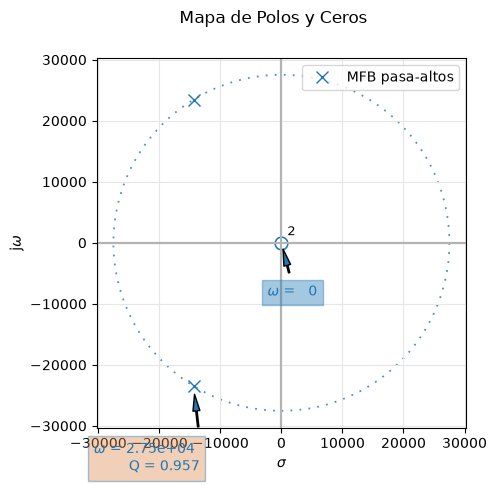

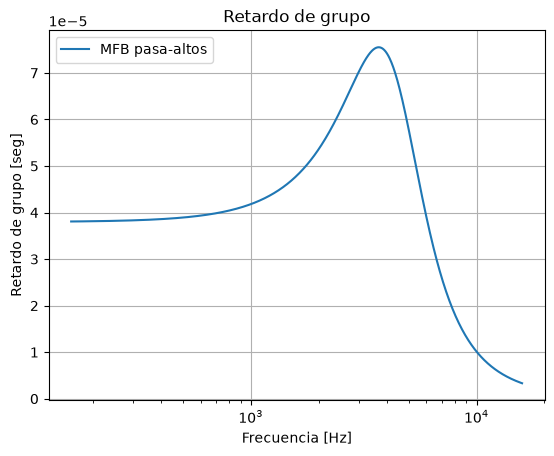

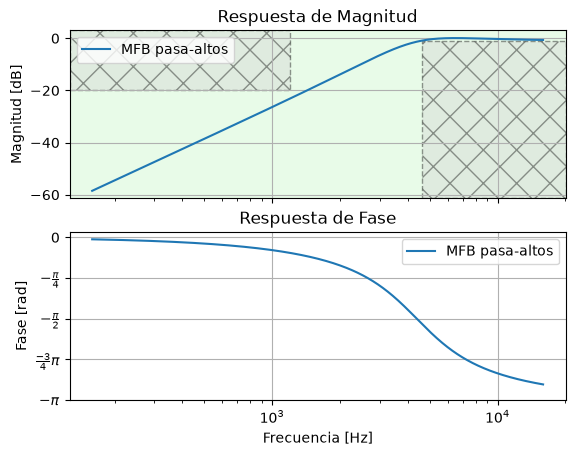

In [11]:
import matplotlib.patches

resultados = analyze_sys([H_teorico], sys_name=['MFB pasa-altos'], xaxis='freq', fs=2*np.pi)


ax_magnitud = resultados[0][1][0]

ax_pz = resultados[1][1]
for patch in ax_pz.patches:
    if isinstance(patch, matplotlib.patches.Circle):
        patch.set_linewidth(1.3)
        patch.set_linestyle((0, (1, 4)))
        patch.set_alpha(0.8)

plt.sca(ax_magnitud)
plot_plantilla(filter_type='highpass', fpass=fc, ripple=Amax, fstop=fs, attenuation=Amin, fs=2*1e5)
plt.show()

# arrays de frecuencia y magnitud en dB para reutilizar en las comparaciones con mediciones
f_axis = np.logspace(1, 5, 2000)
_, H_resp = sig.freqresp(H_teorico, 2*np.pi*f_axis)
H_dB = 20*np.log10(np.abs(H_resp))
ganancia_pb_dB = 20*np.log10(abs(ganancia_hf))

## 4. Simulación en LTSpice

Se simuló el circuito MFB con los componentes reales (R1=1.31kΩ, R2=10.08kΩ, C1=9nF, C2=C3=10nF)
mediante un análisis `.ac dec` de 1Hz a 100kHz, usando el modelo real del amplificador operacional
**TL071**. Los datos se exportaron como texto y se comparan a continuación contra la curva teórica.

![Esquemático del circuito](imagenes/Esquematico-LTSpice.png)

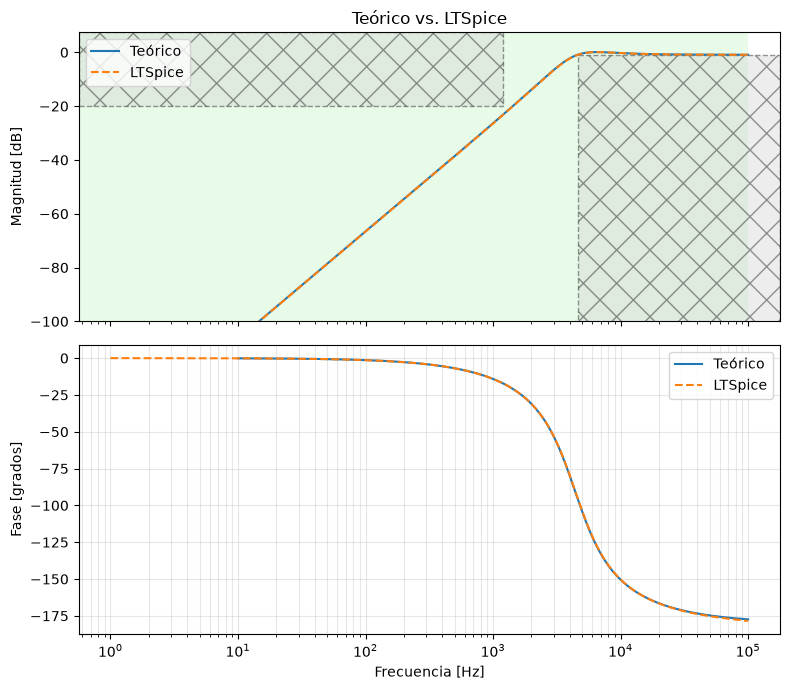

In [12]:
import re

def cargar_ltspice(path):
    freqs, mags, phases = [], [], []
    patron = re.compile(r'\(([-\d.eE+]+)dB,\s*([-\d.eE+]+)')
    with open(path, encoding='cp1252') as f:
        next(f)  # salteamos el encabezado
        for line in f:
            line = line.strip()
            if not line:
                continue
            partes = line.split('\t')
            if len(partes) != 2:
                continue
            m = patron.search(partes[1])
            if m:
                freqs.append(float(partes[0]))
                mags.append(float(m.group(1)))
                phases.append(float(m.group(2)))
    return pd.DataFrame({'freq': freqs, 'mag_dB': mags, 'phase_deg': phases})

ltspice_df = cargar_ltspice('highpass_mfb.txt') 

fig, (ax_mag, ax_fase) = plt.subplots(2, 1, figsize=(8,7), sharex=True)

ax_mag.semilogx(f_axis, H_dB, label='Teórico')
ax_mag.semilogx(ltspice_df['freq'], ltspice_df['mag_dB'], label='LTSpice', linestyle='--')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.set_title('Teórico vs. LTSpice')
ax_mag.legend()
plt.sca(ax_mag)
plot_plantilla(filter_type='highpass', fpass=fc, ripple=Amax, fstop=fs, attenuation=Amin, fs=2*1e5)

ax_fase.semilogx(f_axis, np.degrees(np.angle(H_resp)), label='Teórico')
ax_fase.semilogx(ltspice_df['freq'], ltspice_df['phase_deg'], label='LTSpice', linestyle='--')
ax_fase.set_xlabel('Frecuencia [Hz]')
ax_fase.set_ylabel('Fase [grados]')
ax_fase.legend()
ax_fase.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

 ## 5. Diseño de hardware

Para el esquemáticon y el diseño del PCB se utilizó el software Altium Designer.

### 5.1 Esquemático

![Esquemático del filtro](imagenes/esquematico.png)

### 5.2 PCB

**Vista superior** 

![Layout de la placa - vista superior](imagenes/pcb1.png)

**Vista inferior** 

<img src="imagenes/pcb2.png" width="680">

### 5.3 Placa armada

![Placa armada](imagenes/placaarmada.png)

## 6. Procedimiento experimental

###  6.1 Instrumental utilizado

| Instrumento | Tipo | Fabricante | Modelo | N° Serie |
|---|---|---|---|---|
| Fuente de alimentación | Fuente de tensión continua Regulable | V&A Instruments | HY3005D | NG 1818 |
| Fuente de alimentación | Fuente de tensión continua Regulable | V&A Instruments | HY3005D | NG 1807 |
| Señal de entrada | Generador de señales senoidales hasta 5MHz | Twintex | TFG-3205E | NG 1906 |
| Osciloscopio | Osciloscopio digital de 70MHz, 1G Sa/s | GW Instek | GDS-10772A-U | NG 1393 |

###  6.2 Método de medición

Se armó el circuito en la placa, alimentado con una fuente partida de ±12V (usando dos fuentes
de tensión continua regulables configuradas de forma independiente). La entrada del filtro se
excitó con un generador de funciones en modo senoidal, con amplitud fija, recorriendo el rango
de frecuencias de interés (100 Hz a 100 kHz).

En cada frecuencia se midieron con el osciloscopio tres magnitudes:
- Tensión pico a pico de entrada ($V_i$), en el canal 1.
- Tensión pico a pico de salida ($V_o$), en el canal 2.
- Desfasaje temporal ($\Delta t$) entre ambas señales, medido con los cursores del osciloscopio.

Se tomaron más puntos de medición en el entorno de $f_s$ y $f_c$ y puntos más espaciados en las zonas ya establecidas de
banda de paso y banda de stop.

A partir de los datos crudos, la ganancia en cada punto se calculó como:

$$Ganancia\ [dB] = 20\log_{10}\left(\frac{V_o}{V_i}\right)$$

y la fase, a partir del desfasaje temporal medido y el período de la señal en esa frecuencia:

$$\varphi\ [°] = \Delta t \cdot f \cdot 360°$$

## 7. Resultados experimentales

### 7.1 Primera medición

In [13]:
medicion_1 = pd.DataFrame({
    "freq":  [100,500,800,1000,1200,1500,2000,2500,3000,3500,4000,4600,5500,6500,8000,10000,15000,25000,50000,100000],
    "Vi_mV": [390,410,410,410,410,410,410,410,410,410,410,378,410,410,402,371,371,292,292,292],
    "Vo_mV": [7.97,32.4,49.2,62.5,74.2,91.8,123,148,167,191,207,261,246,261,316,289,289,257,257,257],
    "dt_us": [2600,500,320,320,240,202,158,138,112,102,95,87,73,66,54,44.4,29.2,18.8,9,5],
})

medicion_1["ganancia_dB"] = 20*np.log10(medicion_1["Vo_mV"]/medicion_1["Vi_mV"])
medicion_1["fase_deg"] = -medicion_1["dt_us"]*1e-6 * medicion_1["freq"] * 360
medicion_1

,freq,Vi_mV,Vo_mV,dt_us,ganancia_dB,fase_deg
0,100,390,7.97,2600.0,-33.792126,-93.600
1,500,410,32.40,500.0,-22.044777,-90.000
2,800,410,49.20,320.0,-18.416375,-92.160
3,1000,410,62.50,320.0,-16.338077,-115.200
4,1200,410,74.20,240.0,-14.847599,-103.680
5,1500,410,91.80,202.0,-12.998824,-109.080
6,2000,410,123.00,158.0,-10.457575,-113.760
7,2500,410,148.00,138.0,-8.850443,-124.200
8,3000,410,167.00,112.0,-7.801348,-120.960
9,3500,410,191.00,102.0,-6.635010,-128.520


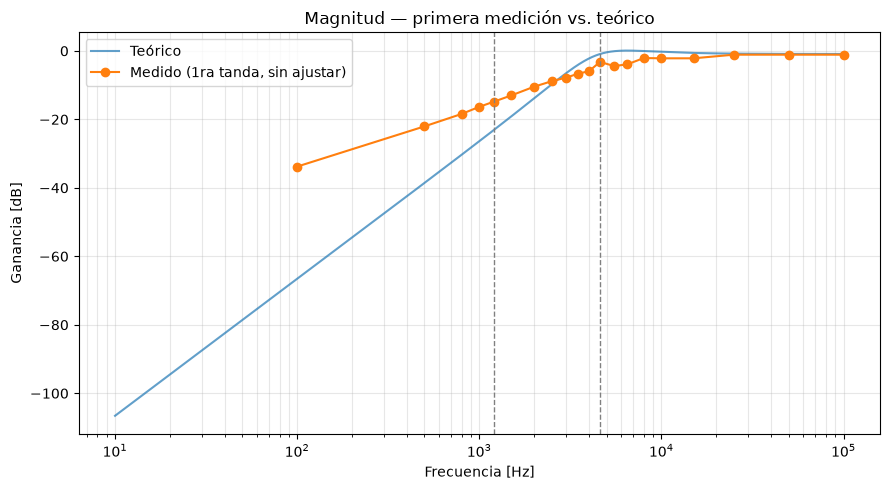

In [14]:
fig, ax = plt.subplots(figsize=(9,5))
ax.semilogx(f_axis, H_dB, label="Teórico", alpha=0.7)
ax.semilogx(medicion_1["freq"], medicion_1["ganancia_dB"], "o-", label="Medido (1ra tanda, sin ajustar)")
ax.axvline(fc, color="gray", linestyle="--", linewidth=1)
ax.axvline(fs, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Ganancia [dB]")
ax.set_title("Magnitud — primera medición vs. teórico")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

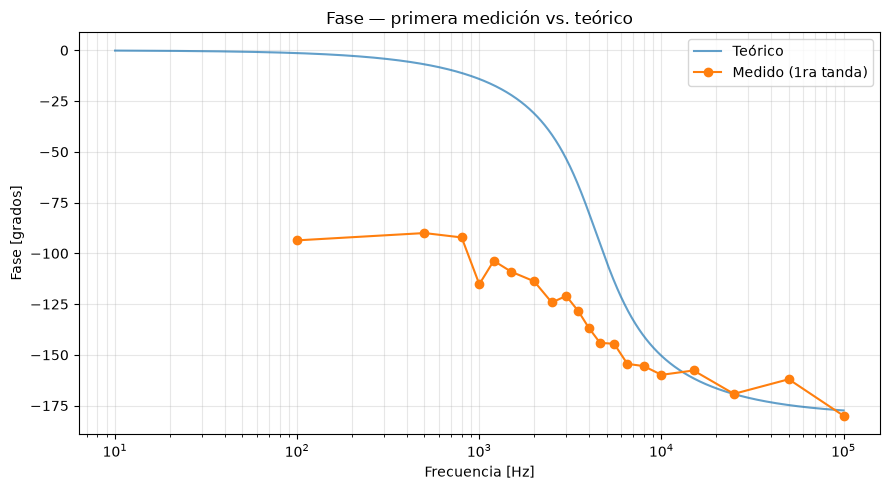

In [15]:
fig, ax = plt.subplots(figsize=(9,5))
ax.semilogx(f_axis, np.degrees(np.angle(H_resp)), label="Teórico", alpha=0.7)
ax.semilogx(medicion_1["freq"], medicion_1["fase_deg"], "o-", label="Medido (1ra tanda)")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Fase [grados]")
ax.set_title("Fase — primera medición vs. teórico")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Resultado:** la curva medida aparece corrida hacia frecuencias más altas que la
teórica. Se determinó que los presets de R1 y R2 estaban en su valor mínimo de fábrica (0 Ω
efectivo), dando un $f_0$ real ≈5.56 kHz en lugar de los 4.38 kHz de diseño. Además se detectó que
el preset estaba conectado usando ambos extremos fijos sin aprovechar el cursor, por lo que
girarlo no producía ningún cambio.


### 7.2 Corrección aplicada

Se corrigió la conexión del preset (cursor + un extremo, dejando el otro sin conectar) y se
reajustaron ambos presets a los valores calculados en la sección 3.8:

- **R1**: 1kΩ fijo + preset ajustado a ≈310Ω (de un preset de 500Ω) → R1 total ≈ 1.31kΩ
- **R2**: 8.2kΩ fijo + preset ajustado a ≈1.9kΩ (de un preset de 5kΩ) → R2 total ≈ 10.1kΩ

### 7.3 Medición final

Con los presets ya corregidos, se repitió el barrido de frecuencias con la misma metodología,
esta vez verificando la ubicación correcta de los cursores de fase.

In [16]:
medicion_2 = pd.DataFrame({
    "freq":  [100,500,800,1000,1200,1500,2000,2500,3000,3500,4000,4600,5500,6500,8000,10000,15000,25000,50000,100000],
    "Vi_mV": [1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1005,1006,1003.5,999,999,999,998,992,961],
    "Vo_mV": [0.8,11.9,33,44,73,130,195,340,456,646,786,901,978,989,979,957,915,893,881,835],
    "dt_us": [39,39.5,39,40,41,42,44,47,51,53,57,58,57,55,48,41,29,17,9,4],
})

medicion_2["ganancia_dB"] = 20*np.log10(medicion_2["Vo_mV"]/medicion_2["Vi_mV"])
medicion_2["fase_deg"] = -medicion_2["dt_us"]*1e-6 * medicion_2["freq"] * 360

medicion_2

,freq,Vi_mV,Vo_mV,dt_us,ganancia_dB,fase_deg
0,100,1000.0,0.8,39.0,-61.938200,-1.404
1,500,1000.0,11.9,39.5,-38.489061,-7.110
2,800,1000.0,33.0,39.0,-29.629721,-11.232
3,1000,1000.0,44.0,40.0,-27.130946,-14.400
4,1200,1000.0,73.0,41.0,-22.733543,-17.712
5,1500,1000.0,130.0,42.0,-17.721133,-22.680
6,2000,1000.0,195.0,44.0,-14.199308,-31.680
7,2500,1000.0,340.0,47.0,-9.370422,-42.300
8,3000,1000.0,456.0,51.0,-6.820703,-55.080
9,3500,1000.0,646.0,53.0,-3.795350,-66.780


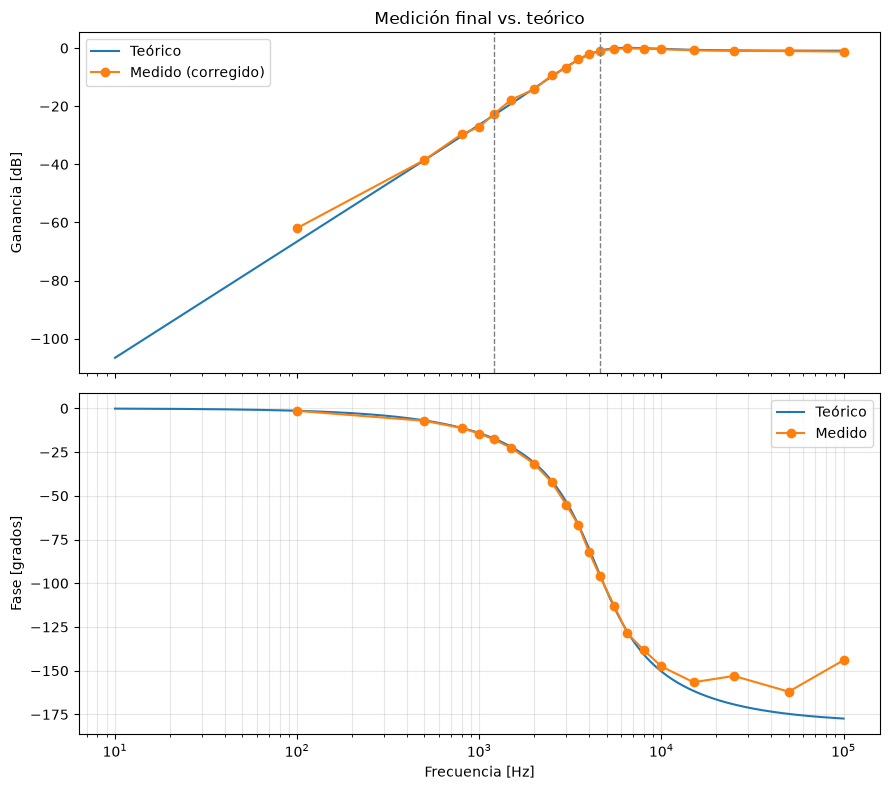

Ganancia en fs=1200.0Hz: -22.73 dB (requerido: <= -20.0 dB)
Ganancia en fc=4600.0Hz: -0.95 dB (requerido: >= -1.0 dB)


In [17]:
fig, (ax_mag, ax_fase) = plt.subplots(2, 1, figsize=(9,8), sharex=True)

ax_mag.semilogx(f_axis, H_dB, label="Teórico")
ax_mag.semilogx(medicion_2["freq"], medicion_2["ganancia_dB"], "o-", label="Medido (corregido)")
ax_mag.axvline(fc, color="gray", linestyle="--", linewidth=1)
ax_mag.axvline(fs, color="gray", linestyle="--", linewidth=1)
ax_mag.set_ylabel("Ganancia [dB]")
ax_mag.set_title("Medición final vs. teórico")
ax_mag.legend()

ax_fase.semilogx(f_axis, np.degrees(np.angle(H_resp)), label="Teórico")
ax_fase.semilogx(medicion_2["freq"], medicion_2["fase_deg"], "o-", label="Medido")
ax_fase.set_xlabel("Frecuencia [Hz]")
ax_fase.set_ylabel("Fase [grados]")
ax_fase.legend()
ax_fase.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Ganancia en fs={fs}Hz: {medicion_2.loc[medicion_2.freq==fs,'ganancia_dB'].values[0]:.2f} dB (requerido: <= -{Amin} dB)")
print(f"Ganancia en fc={fc}Hz: {medicion_2.loc[medicion_2.freq==fc,'ganancia_dB'].values[0]:.2f} dB (requerido: >= -{Amax} dB)")

**Resultado:** la medición final cumple la plantilla con margen en ambos extremos: en $f_s$ se
obtuvo una atenuación mayor a la requerida, y en $f_c$ el rizado quedó dentro de lo permitido. La
fase medida coincide muy bien con la curva teórica en todo el rango, con una leve dispersión por
encima de 25kHz atribuible a la resolución del osciloscopio al medir intervalos de tiempo muy
cortos (algunos microsegundos).

## 8. Comparación teórico – simulado – medido


Se carga la simulación de LTSpice (modelo real del TL071) y se superponen las tres fuentes:
teórico, LTSpice y medición final.

In [18]:
def cargar_ltspice(path):
    freqs, mags, phases = [], [], []
    patron = re.compile(r'\(([-\d.eE+]+)dB,\s*([-\d.eE+]+)')
    with open(path, encoding='cp1252') as f:
        next(f)
        for line in f:
            line = line.strip()
            if not line:
                continue
            partes = line.split('\t')
            if len(partes) != 2:
                continue
            m = patron.search(partes[1])
            if m:
                freqs.append(float(partes[0]))
                mags.append(float(m.group(1)))
                phases.append(float(m.group(2)))
    return pd.DataFrame({'freq': freqs, 'mag_dB': mags, 'phase_deg': phases})

ltspice_df = cargar_ltspice("highpass_mfb.txt") 

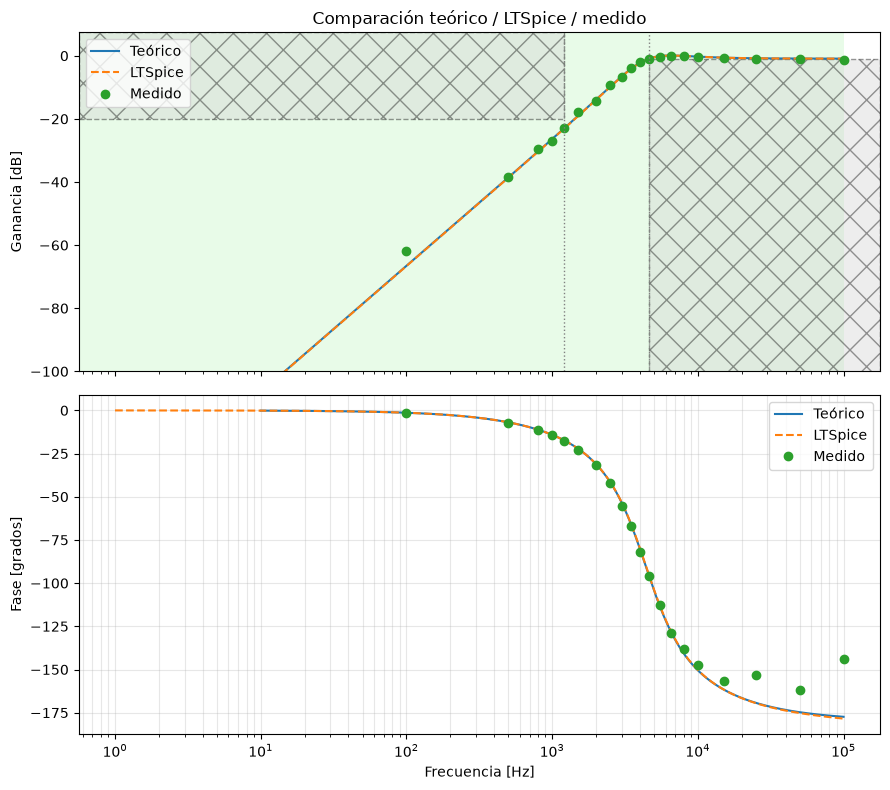

In [19]:
fig, (ax_mag, ax_fase) = plt.subplots(2, 1, figsize=(9,8), sharex=True)

ax_mag.semilogx(f_axis, H_dB, label="Teórico")
ax_mag.semilogx(ltspice_df["freq"], ltspice_df["mag_dB"], label="LTSpice", linestyle="--")
ax_mag.semilogx(medicion_2["freq"], medicion_2["ganancia_dB"], "o", label="Medido")
ax_mag.axvline(fc, color="gray", linestyle=":", linewidth=1)
ax_mag.axvline(fs, color="gray", linestyle=":", linewidth=1)
ax_mag.set_ylabel("Ganancia [dB]")
ax_mag.set_title("Comparación teórico / LTSpice / medido")
ax_mag.legend()
plt.sca(ax_mag)
plot_plantilla(filter_type='highpass', fpass=fc, ripple=Amax, fstop=fs, attenuation=Amin, fs=2*1e5)

ax_fase.semilogx(f_axis, np.degrees(np.angle(H_resp)), label="Teórico")
ax_fase.semilogx(ltspice_df["freq"], ltspice_df["phase_deg"], label="LTSpice", linestyle="--")
ax_fase.semilogx(medicion_2["freq"], medicion_2["fase_deg"], "o", label="Medido")
ax_fase.set_xlabel("Frecuencia [Hz]")
ax_fase.set_ylabel("Fase [grados]")
ax_fase.legend()
ax_fase.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Conclusiones

El filtro diseñado (Chebyshev pasa altos de 2° orden, topología MFB) cumplió la plantilla asignada
tanto en el análisis teórico como en la simulación LTSpice y, finalmente, en la medición física.
Las tres fuentes coinciden dentro de fracciones de dB y pocos grados de fase en todo el rango de
100Hz a 100kHz.

El camino hasta ese resultado no fue directo: la primera medición reveló un filtro corrido en
frecuencia, cuya causa resultó ser una conexión incorrecta del preset (usando sus dos extremos
fijos en vez de cursor + un extremo), sumada a un error de posicionamiento de cursores en la
medición de fase. Ambos problemas se identificaron comparando sistemáticamente los datos medidos
contra la curva teórica, y se corrigieron sin necesidad de rediseñar nada del circuito, el modelo
teórico y el circuito ya estaban bien calculados desde el principio.

Esto deja como aprendizaje principal que gran parte del trabajo de un diseño analógico no termina
en el cálculo ni en la simulación: la puesta a punto experimental exige diagnosticar
metódicamente cualquier desvío entre lo esperado y lo medido, en lugar de asumir que el circuito
"está mal", en este caso, tanto el circuito como los cálculos eran correctos desde el inicio, y
los desvíos observados se debieron enteramente a errores de armado y de medición, no de diseño.